In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# ---- Config ----
NUM_ZONES = 6
NUM_READINGS = 200          # simulated readings per zone
READING_INTERVAL_SEC = 60   # 1 reading/minute

# Pest-risk thresholds (from your plan: humidity/temp range favoring pest activity)
HUMIDITY_RISK_MIN = 80      # % RH
TEMP_RISK_MIN = 25          # °C
TEMP_RISK_MAX = 32          # °C

zone_names = [f"Zone_{i+1}" for i in range(NUM_ZONES)]

# Randomly pick which zones will develop pest-risk conditions (hidden, like a "ground truth")
num_risky = np.random.randint(0, 3)  # 0, 1, or 2 risky zones this run
risky_zones = list(np.random.choice(zone_names, size=num_risky, replace=False))
print("Hidden ground truth (risky zones):", risky_zones)

def generate_zone_data(zone_name, is_risky):
    humidity = np.random.normal(60, 5, NUM_READINGS)   # normal baseline ~60% RH
    temperature = np.random.normal(28, 2, NUM_READINGS) # normal baseline ~28°C
    soil_moisture = np.random.normal(40, 5, NUM_READINGS)

    if is_risky:
        # after some point, humidity climbs into risk range and stays there
        onset = np.random.randint(60, 120)
        humidity[onset:] += np.linspace(0, 25, NUM_READINGS - onset)
        humidity[onset:] = np.clip(humidity[onset:], 0, 100)

    return pd.DataFrame({
        "zone": zone_name,
        "reading_num": np.arange(NUM_READINGS),
        "humidity": humidity,
        "temperature": temperature,
        "soil_moisture": soil_moisture,
    })

all_data = pd.concat(
    [generate_zone_data(z, z in risky_zones) for z in zone_names],
    ignore_index=True
)

print(all_data.head())

Hidden ground truth (risky zones): [np.str_('Zone_1'), np.str_('Zone_2')]
     zone  reading_num   humidity  temperature  soil_moisture
0  Zone_1            0  54.440599    29.744894      35.860535
1  Zone_1            1  61.594511    30.132397      38.480678
2  Zone_1            2  61.395206    26.081984      41.211668
3  Zone_1            3  65.052576    30.764009      50.236995
4  Zone_1            4  57.095609    29.810244      40.574307


In [19]:
def check_pest_risk(row):
    return (row["humidity"] >= HUMIDITY_RISK_MIN and
            TEMP_RISK_MIN <= row["temperature"] <= TEMP_RISK_MAX)

all_data["pest_risk_flag"] = all_data.apply(check_pest_risk, axis=1)

def detect_risky_zones(df, sustained_readings=5):
    """A zone is flagged only if risk condition holds for several consecutive readings
    (avoids false alerts from a single noisy reading)."""
    alerts = {}
    for zone in df["zone"].unique():
        zdf = df[df["zone"] == zone].reset_index(drop=True)
        flags = zdf["pest_risk_flag"].values
        streak = 0
        for i, f in enumerate(flags):
            streak = streak + 1 if f else 0
            if streak >= sustained_readings:
                alerts[zone] = i - sustained_readings + 1  # first reading of the sustained streak
                break
    return alerts

detected = detect_risky_zones(all_data)

print("\n--- ALERTS ---")
if not detected:
    print("No zones currently at pest risk.")
else:
    for zone, idx in detected.items():
        print(f"⚠️  {zone}: pest-risk conditions detected starting at reading #{idx} "
              f"(humidity ≥ {HUMIDITY_RISK_MIN}%, temp in {TEMP_RISK_MIN}-{TEMP_RISK_MAX}°C)")

print("\nActual risky zones (ground truth):", risky_zones)
print("Detected zones:", list(detected.keys()))


--- ALERTS ---
⚠️  Zone_1: pest-risk conditions detected starting at reading #181 (humidity ≥ 80%, temp in 25-32°C)
⚠️  Zone_2: pest-risk conditions detected starting at reading #177 (humidity ≥ 80%, temp in 25-32°C)

Actual risky zones (ground truth): [np.str_('Zone_1'), np.str_('Zone_2')]
Detected zones: ['Zone_1', 'Zone_2']


In [20]:
# ---- Config for actuation ----
SPRAY_MODE = "auto"   # "auto" = system sprays immediately, "manual" = waits for operator approval
SPRAY_DURATION_READINGS = 3  # how long the pump stays "on" once triggered
COOLDOWN_READINGS = 20        # minimum gap before the same zone can spray again (avoid over-spraying)

spray_log = []  # each entry: zone, trigger_reading, mode, status

def simulate_actuation(df, detected_alerts, mode=SPRAY_MODE):
    for zone, alert_idx in detected_alerts.items():
        zdf = df[df["zone"] == zone].reset_index(drop=True)

        if mode == "auto":
            status = "sprayed"
            spray_start = alert_idx
        else:
            # manual mode: log as "pending operator approval" — no auto spray
            status = "pending_approval"
            spray_start = None

        spray_log.append({
            "zone": zone,
            "alert_reading": alert_idx,
            "mode": mode,
            "status": status,
            "spray_start_reading": spray_start,
            "spray_end_reading": (spray_start + SPRAY_DURATION_READINGS) if spray_start is not None else None,
        })

simulate_actuation(all_data, detected, mode=SPRAY_MODE)

spray_df = pd.DataFrame(spray_log)
print("--- SPRAY LOG ---")
print(spray_df.to_string(index=False))

--- SPRAY LOG ---
  zone  alert_reading mode  status  spray_start_reading  spray_end_reading
Zone_1            181 auto sprayed                  181                184
Zone_2            177 auto sprayed                  177                180


In [21]:
def approve_spray(zone_name):
    """Call this to simulate an operator approving a pending spray."""
    for entry in spray_log:
        if entry["zone"] == zone_name and entry["status"] == "pending_approval":
            entry["status"] = "sprayed"
            entry["spray_start_reading"] = entry["alert_reading"]
            entry["spray_end_reading"] = entry["alert_reading"] + SPRAY_DURATION_READINGS
            print(f"✅ Spray approved and triggered for {zone_name}")
            return
    print(f"No pending spray found for {zone_name}")

# Try it in manual mode, e.g.:
# SPRAY_MODE = "manual"
# simulate_actuation(all_data, detected, mode="manual")
# approve_spray("Zone_1")

In [22]:
from collections import defaultdict
from datetime import datetime, timedelta

# ---- Simulated MQTT broker ----
class FakeBroker:
    def __init__(self):
        self.topics = defaultdict(list)  # topic -> list of messages

    def publish(self, topic, message):
        self.topics[topic].append(message)

    def get_latest(self, topic, n=1):
        return self.topics[topic][-n:]

broker = FakeBroker()

# Publish each zone's latest reading + alert + spray status as if nodes were reporting live
base_time = datetime.now() - timedelta(seconds=NUM_READINGS * READING_INTERVAL_SEC)

def publish_zone_status(zone, reading_num, df, alerts, sprays):
    row = df[(df["zone"] == zone) & (df["reading_num"] == reading_num)].iloc[0]
    timestamp = base_time + timedelta(seconds=reading_num * READING_INTERVAL_SEC)

    payload = {
        "zone": zone,
        "timestamp": timestamp.strftime("%Y-%m-%d %H:%M:%S"),
        "humidity": round(row["humidity"], 1),
        "temperature": round(row["temperature"], 1),
        "soil_moisture": round(row["soil_moisture"], 1),
        "pest_risk": zone in alerts and reading_num >= alerts[zone],
        "spray_status": next((s["status"] for s in sprays if s["zone"] == zone), "idle"),
    }
    broker.publish(f"farm/{zone}/status", payload)
    return payload

# Publish the latest reading for every zone
latest_payloads = [
    publish_zone_status(z, NUM_READINGS - 1, all_data, detected, spray_log)
    for z in zone_names
]

for p in latest_payloads:
    print(p)

{'zone': 'Zone_1', 'timestamp': '2026-09-17 11:52:59', 'humidity': np.float64(85.3), 'temperature': np.float64(31.1), 'soil_moisture': np.float64(37.4), 'pest_risk': True, 'spray_status': 'sprayed'}
{'zone': 'Zone_2', 'timestamp': '2026-09-17 11:52:59', 'humidity': np.float64(91.5), 'temperature': np.float64(30.6), 'soil_moisture': np.float64(51.3), 'pest_risk': True, 'spray_status': 'sprayed'}
{'zone': 'Zone_3', 'timestamp': '2026-09-17 11:52:59', 'humidity': np.float64(56.2), 'temperature': np.float64(26.1), 'soil_moisture': np.float64(32.1), 'pest_risk': False, 'spray_status': 'idle'}
{'zone': 'Zone_4', 'timestamp': '2026-09-17 11:52:59', 'humidity': np.float64(61.1), 'temperature': np.float64(28.9), 'soil_moisture': np.float64(46.7), 'pest_risk': False, 'spray_status': 'idle'}
{'zone': 'Zone_5', 'timestamp': '2026-09-17 11:52:59', 'humidity': np.float64(59.1), 'temperature': np.float64(24.4), 'soil_moisture': np.float64(33.3), 'pest_risk': False, 'spray_status': 'idle'}
{'zone': 'Z


=== LIVE FIELD DASHBOARD ===
  zone           timestamp  humidity  temperature  soil_moisture  pest_risk spray_status
Zone_1 2026-09-17 11:52:59      85.3         31.1           37.4       True      sprayed
Zone_2 2026-09-17 11:52:59      91.5         30.6           51.3       True      sprayed
Zone_3 2026-09-17 11:52:59      56.2         26.1           32.1      False         idle
Zone_4 2026-09-17 11:52:59      61.1         28.9           46.7      False         idle
Zone_5 2026-09-17 11:52:59      59.1         24.4           33.3      False         idle
Zone_6 2026-09-17 11:52:59      56.6         22.9           36.0      False         idle


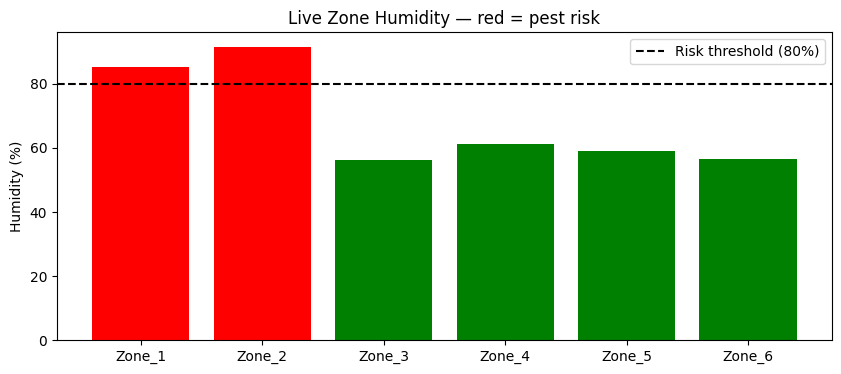

In [23]:
dashboard_df = pd.DataFrame(latest_payloads)
print("\n=== LIVE FIELD DASHBOARD ===")
print(dashboard_df.to_string(index=False))

# Visual: humidity per zone, color-coded by risk
plt.figure(figsize=(10, 4))
colors = ["red" if r else "green" for r in dashboard_df["pest_risk"]]
plt.bar(dashboard_df["zone"], dashboard_df["humidity"], color=colors)
plt.axhline(HUMIDITY_RISK_MIN, color="black", linestyle="--", label=f"Risk threshold ({HUMIDITY_RISK_MIN}%)")
plt.ylabel("Humidity (%)")
plt.title("Live Zone Humidity — red = pest risk")
plt.legend()
plt.show()

In [24]:
import ipywidgets as widgets
from IPython.display import display, clear_output

zone_dropdown = widgets.Dropdown(options=zone_names, description="Zone:")
mode_dropdown = widgets.Dropdown(options=["auto", "manual"], description="Spray mode:")
simulate_button = widgets.Button(description="Simulate Pest Risk", button_style="danger")
approve_button = widgets.Button(description="Approve Spray (manual mode)", button_style="warning")
output = widgets.Output()

def run_demo(target_zone, mode):
    # Fresh data: force the chosen zone to develop pest-risk conditions, others stay healthy
    demo_data = pd.concat(
        [generate_zone_data(z, is_risky=(z == target_zone)) for z in zone_names],
        ignore_index=True
    )
    demo_data["pest_risk_flag"] = demo_data.apply(check_pest_risk, axis=1)
    demo_alerts = detect_risky_zones(demo_data)

    global spray_log
    spray_log = []
    simulate_actuation(demo_data, demo_alerts, mode=mode)

    print(f"--- Simulating {target_zone} developing pest-risk conditions ---\n")
    if target_zone in demo_alerts:
        print(f"⚠️  ALERT: {target_zone} flagged at reading #{demo_alerts[target_zone]}")
    else:
        print(f"No alert triggered for {target_zone} in this run (try again — conditions are randomized).")

    print("\n--- Spray Log ---")
    print(pd.DataFrame(spray_log).to_string(index=False) if spray_log else "No spray actions yet.")

    # Plot the target zone's humidity trend with the risk threshold
    zdf = demo_data[demo_data["zone"] == target_zone]
    plt.figure(figsize=(9, 4))
    plt.plot(zdf["reading_num"], zdf["humidity"], label="Humidity (%)")
    plt.axhline(HUMIDITY_RISK_MIN, color="red", linestyle="--", label="Risk threshold")
    if target_zone in demo_alerts:
        plt.axvline(demo_alerts[target_zone], color="orange", linestyle=":", label="Alert triggered")
    plt.title(f"{target_zone} — Live Simulation")
    plt.xlabel("Reading #")
    plt.legend()
    plt.show()

    return demo_alerts

current_alerts = {}

def on_simulate_click(b):
    global current_alerts
    with output:
        clear_output(wait=True)
        current_alerts = run_demo(zone_dropdown.value, mode_dropdown.value)

def on_approve_click(b):
    with output:
        if zone_dropdown.value in current_alerts:
            approve_spray(zone_dropdown.value)
            print(pd.DataFrame(spray_log).to_string(index=False))
        else:
            print("No pending alert for this zone — click 'Simulate Pest Risk' first.")

simulate_button.on_click(on_simulate_click)
approve_button.on_click(on_approve_click)

display(widgets.HBox([zone_dropdown, mode_dropdown]), widgets.HBox([simulate_button, approve_button]), output)

Output()

In [25]:
import time

# A generator seeded by the current time — independent of the np.random.seed(42) used earlier
demo_rng = np.random.default_rng(seed=int(time.time() * 1000) % (2**32))

def generate_zone_data_demo(zone_name, is_risky):
    humidity = demo_rng.normal(60, 5, NUM_READINGS)
    temperature = demo_rng.normal(28, 2, NUM_READINGS)
    soil_moisture = demo_rng.normal(40, 5, NUM_READINGS)

    if is_risky:
        onset = demo_rng.integers(60, 120)
        humidity[onset:] += np.linspace(0, 25, NUM_READINGS - onset)
        humidity[onset:] = np.clip(humidity[onset:], 0, 100)

    return pd.DataFrame({
        "zone": zone_name,
        "reading_num": np.arange(NUM_READINGS),
        "humidity": humidity,
        "temperature": temperature,
        "soil_moisture": soil_moisture,
    })

In [26]:
def run_demo(target_zone, mode):
    demo_data = pd.concat(
        [generate_zone_data_demo(z, is_risky=(z == target_zone)) for z in zone_names],
        ignore_index=True
    )
    # ...rest of the function stays exactly the same

In [27]:
import ipywidgets as widgets
from IPython.display import display, clear_output

zone_dropdown = widgets.Dropdown(options=zone_names, description="Zone:")
mode_dropdown = widgets.Dropdown(options=["auto", "manual"], description="Spray mode:")
simulate_button = widgets.Button(description="Simulate Pest Risk", button_style="danger")
approve_button = widgets.Button(description="Approve Spray (manual mode)", button_style="warning")
output = widgets.Output()

def run_demo(target_zone, mode):
    # Fresh data: force the chosen zone to develop pest-risk conditions, others stay healthy
    demo_data = pd.concat(
        [generate_zone_data(z, is_risky=(z == target_zone)) for z in zone_names],
        ignore_index=True
    )
    demo_data["pest_risk_flag"] = demo_data.apply(check_pest_risk, axis=1)
    demo_alerts = detect_risky_zones(demo_data)

    global spray_log
    spray_log = []
    simulate_actuation(demo_data, demo_alerts, mode=mode)

    print(f"--- Simulating {target_zone} developing pest-risk conditions ---\n")
    if target_zone in demo_alerts:
        print(f"⚠️  ALERT: {target_zone} flagged at reading #{demo_alerts[target_zone]}")
    else:
        print(f"No alert triggered for {target_zone} in this run (try again — conditions are randomized).")

    print("\n--- Spray Log ---")
    print(pd.DataFrame(spray_log).to_string(index=False) if spray_log else "No spray actions yet.")

    # Plot the target zone's humidity trend with the risk threshold
    zdf = demo_data[demo_data["zone"] == target_zone]
    plt.figure(figsize=(9, 4))
    plt.plot(zdf["reading_num"], zdf["humidity"], label="Humidity (%)")
    plt.axhline(HUMIDITY_RISK_MIN, color="red", linestyle="--", label="Risk threshold")
    if target_zone in demo_alerts:
        plt.axvline(demo_alerts[target_zone], color="orange", linestyle=":", label="Alert triggered")
    plt.title(f"{target_zone} — Live Simulation")
    plt.xlabel("Reading #")
    plt.legend()
    plt.show()

    return demo_alerts

current_alerts = {}

def on_simulate_click(b):
    global current_alerts
    with output:
        clear_output(wait=True)
        current_alerts = run_demo(zone_dropdown.value, mode_dropdown.value)

def on_approve_click(b):
    with output:
        if zone_dropdown.value in current_alerts:
            approve_spray(zone_dropdown.value)
            print(pd.DataFrame(spray_log).to_string(index=False))
        else:
            print("No pending alert for this zone — click 'Simulate Pest Risk' first.")

simulate_button.on_click(on_simulate_click)
approve_button.on_click(on_approve_click)

display(widgets.HBox([zone_dropdown, mode_dropdown]), widgets.HBox([simulate_button, approve_button]), output)

Output()

In [28]:
import pandas as pd
import numpy as np

# ---- Build a larger labeled training set by reusing the existing simulator ----
NUM_TRAINING_RUNS = 300  # each run = one simulated zone's full time series

training_rows = []

for run in range(NUM_TRAINING_RUNS):
    is_risky = np.random.rand() < 0.35  # ~35% of simulated zones will develop risk
    df = generate_zone_data(f"train_{run}", is_risky)
    # Label each reading using the existing threshold rule (our source of truth for labeling)
    df["label"] = df.apply(check_pest_risk, axis=1).astype(int)
    training_rows.append(df)

train_df = pd.concat(training_rows, ignore_index=True)
print(f"Training rows: {len(train_df)}")
print(train_df["label"].value_counts())
print(train_df.head())

Training rows: 60000
label
0    57825
1     2175
Name: count, dtype: int64
      zone  reading_num   humidity  temperature  soil_moisture  label
0  train_0            0  55.966268    29.580757      39.469402      0
1  train_0            1  51.536592    30.601054      48.523255      0
2  train_0            2  62.798502    28.326811      51.953831      0
3  train_0            3  60.937694    25.608752      41.885460      0
4  train_0            4  65.021883    27.558714      39.500151      0


In [29]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Features the model will actually use (no zone name, no label)
FEATURES = ["humidity", "temperature", "soil_moisture"]

X = train_df[FEATURES]
y = train_df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

pest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=8,
    class_weight="balanced",
    random_state=42,
)
pest_model.fit(X_train, y_train)

y_pred = pest_model.predict(X_test)

print("--- Classification Report ---")
print(classification_report(y_test, y_pred, target_names=["Safe", "Pest Risk"]))
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))

# Feature importance — which sensor matters most to the model?
importances = pd.Series(pest_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
print("\n--- Feature Importance ---")
print(importances)

--- Classification Report ---
              precision    recall  f1-score   support

        Safe       1.00      1.00      1.00     11565
   Pest Risk       1.00      1.00      1.00       435

    accuracy                           1.00     12000
   macro avg       1.00      1.00      1.00     12000
weighted avg       1.00      1.00      1.00     12000

--- Confusion Matrix ---
[[11564     1]
 [    1   434]]

--- Feature Importance ---
humidity         0.969777
temperature      0.027848
soil_moisture    0.002376
dtype: float64


--- Simulating Zone_2 developing pest-risk conditions ---

No alert triggered for Zone_2 in this run (try again — conditions are randomized).

--- Spray Log ---
No spray actions yet.


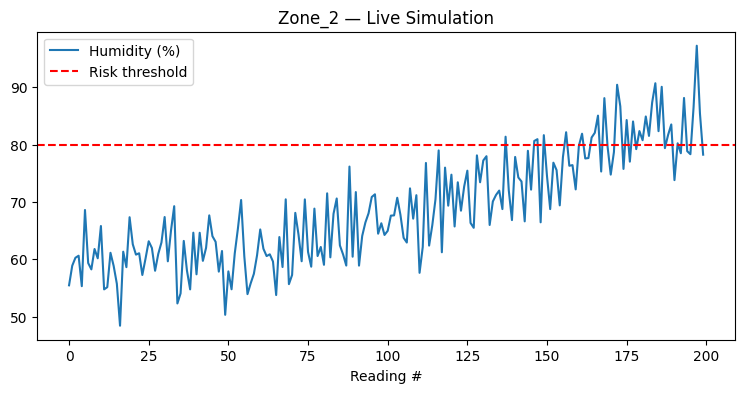

{}

In [30]:
run_demo("Zone_2", "auto")

--- Simulating Zone_2 developing pest-risk conditions ---

⚠️  ALERT: Zone_2 flagged at reading #190

--- Spray Log ---
  zone  alert_reading mode  status  spray_start_reading  spray_end_reading
Zone_2            190 auto sprayed                  190                193


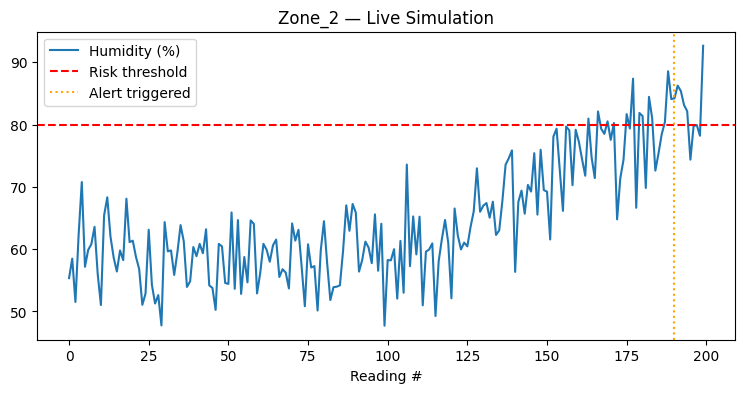

{'Zone_2': 190}

In [31]:
run_demo("Zone_2", "auto")

In [35]:
def run_demo(target_zone, mode):
    demo_data = pd.concat(
        [generate_zone_data_demo(z, is_risky=(z == target_zone)) for z in zone_names],
        ignore_index=True
    )
    demo_data["pest_risk_flag"] = demo_data.apply(check_pest_risk_ml, axis=1)
    demo_alerts = detect_risky_zones(demo_data)

    global spray_log
    spray_log = []
    simulate_actuation(demo_data, demo_alerts, mode=mode)

    print(f"--- Simulating {target_zone} developing pest-risk conditions (ML-based) ---\n")
    if target_zone in demo_alerts:
        print(f"⚠️  ALERT: {target_zone} flagged at reading #{demo_alerts[target_zone]}")
        row_at_alert = demo_data[(demo_data["zone"] == target_zone) &
                                   (demo_data["reading_num"] == demo_alerts[target_zone])].iloc[0]
        print(f"   ML risk score at trigger: {get_pest_risk_score(row_at_alert)*100:.1f}%")
    else:
        print(f"No alert triggered for {target_zone} in this run (try again — conditions are randomized).")

    print("\n--- Spray Log ---")
    print(pd.DataFrame(spray_log).to_string(index=False) if spray_log else "No spray actions yet.")

    zdf = demo_data[demo_data["zone"] == target_zone]
    plt.figure(figsize=(9, 4))
    plt.plot(zdf["reading_num"], zdf["humidity"], label="Humidity (%)")
    plt.axhline(HUMIDITY_RISK_MIN, color="gray", linestyle="--", label="Old threshold (reference)")
    if target_zone in demo_alerts:
        plt.axvline(demo_alerts[target_zone], color="orange", linestyle=":", label="ML alert triggered")
    plt.title(f"{target_zone} — Live Simulation (ML-based detection)")
    plt.xlabel("Reading #")
    plt.legend()
    plt.show()

    return demo_alerts

In [36]:
run_demo("Zone_2", "auto")

NameError: name 'check_pest_risk_ml' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from datetime import datetime, timedelta

np.random.seed(42)

# ---- Config ----
NUM_ZONES = 6
NUM_READINGS = 200
HUMIDITY_RISK_MIN = 80
TEMP_RISK_MIN = 25
TEMP_RISK_MAX = 32
FEATURES = ["humidity", "temperature", "soil_moisture"]

zone_names = [f"Zone_{i+1}" for i in range(NUM_ZONES)]

# ---- Day 1: simulator + threshold rule ----
def generate_zone_data(zone_name, is_risky):
    humidity = np.random.normal(60, 5, NUM_READINGS)
    temperature = np.random.normal(28, 2, NUM_READINGS)
    soil_moisture = np.random.normal(40, 5, NUM_READINGS)
    if is_risky:
        onset = np.random.randint(60, 120)
        humidity[onset:] += np.linspace(0, 25, NUM_READINGS - onset)
        humidity[onset:] = np.clip(humidity[onset:], 0, 100)
    return pd.DataFrame({
        "zone": zone_name, "reading_num": np.arange(NUM_READINGS),
        "humidity": humidity, "temperature": temperature, "soil_moisture": soil_moisture,
    })

def check_pest_risk(row):
    return (row["humidity"] >= HUMIDITY_RISK_MIN and
            TEMP_RISK_MIN <= row["temperature"] <= TEMP_RISK_MAX)

def detect_risky_zones(df, sustained_readings=5):
    alerts = {}
    for zone in df["zone"].unique():
        zdf = df[df["zone"] == zone].reset_index(drop=True)
        flags = zdf["pest_risk_flag"].values
        streak = 0
        for i, f in enumerate(flags):
            streak = streak + 1 if f else 0
            if streak >= sustained_readings:
                alerts[zone] = i - sustained_readings + 1
                break
    return alerts

# ---- Day 2: actuation ----
spray_log = []

def simulate_actuation(df, detected_alerts, mode="auto"):
    for zone, alert_idx in detected_alerts.items():
        if mode == "auto":
            status, spray_start = "sprayed", alert_idx
        else:
            status, spray_start = "pending_approval", None
        spray_log.append({
            "zone": zone, "alert_reading": alert_idx, "mode": mode, "status": status,
            "spray_start_reading": spray_start,
            "spray_end_reading": (spray_start + 3) if spray_start is not None else None,
        })

def approve_spray(zone_name):
    for entry in spray_log:
        if entry["zone"] == zone_name and entry["status"] == "pending_approval":
            entry["status"] = "sprayed"
            entry["spray_start_reading"] = entry["alert_reading"]
            entry["spray_end_reading"] = entry["alert_reading"] + 3
            print(f"✅ Spray approved and triggered for {zone_name}")
            return
    print(f"No pending spray found for {zone_name}")

# ---- Day 1 run (baseline dataset) ----
num_risky = np.random.randint(0, 3)
risky_zones = list(np.random.choice(zone_names, size=num_risky, replace=False))
all_data = pd.concat([generate_zone_data(z, z in risky_zones) for z in zone_names], ignore_index=True)
all_data["pest_risk_flag"] = all_data.apply(check_pest_risk, axis=1)
detected = detect_risky_zones(all_data)
simulate_actuation(all_data, detected, mode="auto")
print("Baseline threshold-based alerts:", detected)

# ---- ML training data (reuses generate_zone_data) ----
NUM_TRAINING_RUNS = 300
training_rows = []
for run in range(NUM_TRAINING_RUNS):
    is_risky = np.random.rand() < 0.35
    df = generate_zone_data(f"train_{run}", is_risky)
    df["label"] = df.apply(check_pest_risk, axis=1).astype(int)
    training_rows.append(df)
train_df = pd.concat(training_rows, ignore_index=True)
print(f"\nTraining rows: {len(train_df)}  |  label counts:\n{train_df['label'].value_counts()}")

# ---- Train the model ----
X = train_df[FEATURES]
y = train_df["label"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
pest_model = RandomForestClassifier(n_estimators=150, max_depth=8, class_weight="balanced", random_state=42)
pest_model.fit(X_train, y_train)
print("\nModel trained. Test accuracy:", pest_model.score(X_test, y_test))

# ---- ML-based detection functions ----
def check_pest_risk_ml(row):
    features = pd.DataFrame([[row["humidity"], row["temperature"], row["soil_moisture"]]], columns=FEATURES)
    return pest_model.predict_proba(features)[0][1] >= 0.5

def get_pest_risk_score(row):
    features = pd.DataFrame([[row["humidity"], row["temperature"], row["soil_moisture"]]], columns=FEATURES)
    return pest_model.predict_proba(features)[0][1]

# ---- Demo generator (independent RNG so results genuinely vary each call) ----
import time
demo_rng = np.random.default_rng(seed=int(time.time() * 1000) % (2**32))

def generate_zone_data_demo(zone_name, is_risky):
    humidity = demo_rng.normal(60, 5, NUM_READINGS)
    temperature = demo_rng.normal(28, 2, NUM_READINGS)
    soil_moisture = demo_rng.normal(40, 5, NUM_READINGS)
    if is_risky:
        onset = demo_rng.integers(60, 120)
        humidity[onset:] += np.linspace(0, 25, NUM_READINGS - onset)
        humidity[onset:] = np.clip(humidity[onset:], 0, 100)
    return pd.DataFrame({
        "zone": zone_name, "reading_num": np.arange(NUM_READINGS),
        "humidity": humidity, "temperature": temperature, "soil_moisture": soil_moisture,
    })

def run_demo(target_zone, mode="auto"):
    demo_data = pd.concat(
        [generate_zone_data_demo(z, is_risky=(z == target_zone)) for z in zone_names],
        ignore_index=True
    )
    demo_data["pest_risk_flag"] = demo_data.apply(check_pest_risk_ml, axis=1)
    demo_alerts = detect_risky_zones(demo_data)

    global spray_log
    spray_log = []
    simulate_actuation(demo_data, demo_alerts, mode=mode)

    print(f"--- Simulating {target_zone} developing pest-risk conditions (ML-based) ---\n")
    if target_zone in demo_alerts:
        print(f"⚠️  ALERT: {target_zone} flagged at reading #{demo_alerts[target_zone]}")
        row_at_alert = demo_data[(demo_data["zone"] == target_zone) &
                                   (demo_data["reading_num"] == demo_alerts[target_zone])].iloc[0]
        print(f"   ML risk score at trigger: {get_pest_risk_score(row_at_alert)*100:.1f}%")
    else:
        print(f"No alert triggered for {target_zone} in this run (try again — conditions are randomized).")

    print("\n--- Spray Log ---")
    print(pd.DataFrame(spray_log).to_string(index=False) if spray_log else "No spray actions yet.")

    zdf = demo_data[demo_data["zone"] == target_zone]
    plt.figure(figsize=(9, 4))
    plt.plot(zdf["reading_num"], zdf["humidity"], label="Humidity (%)")
    plt.axhline(HUMIDITY_RISK_MIN, color="gray", linestyle="--", label="Old threshold (reference)")
    if target_zone in demo_alerts:
        plt.axvline(demo_alerts[target_zone], color="orange", linestyle=":", label="ML alert triggered")
    plt.title(f"{target_zone} — Live Simulation (ML-based detection)")
    plt.xlabel("Reading #")
    plt.legend()
    plt.show()

    return demo_alerts

print("\n✅ Everything loaded. Now run: run_demo('Zone_1', 'auto')  in a NEW cell below this one.")

In [ ]:
run_demo("Zone_2", "auto")


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- Config ----
ZONE_NAMES = ["Zone_1", "Zone_2", "Zone_3", "Zone_4", "Zone_5", "Zone_6"]
THRESHOLD = 80
MAX_POINTS = 40
SUSTAIN = 5
SMOOTH_WINDOW = 5

# ---- Per-zone live state ----
def fresh_state():
    return [{
        "raw": [], "smooth": [], "alert": False,
        "risky": np.random.rand() < 0.35,
        "onset": np.random.randint(15, 30),
    } for _ in ZONE_NAMES]

state = fresh_state()
tick = 0
alert_log = []

def step_zone(z):
    base = 60 + np.random.normal(0, 4)
    if z["risky"] and tick > z["onset"]:
        base += min(30, (tick - z["onset"]) * 0.8)
    z["raw"].append(base)
    if len(z["raw"]) > MAX_POINTS:
        z["raw"].pop(0)

    window = z["raw"][-SMOOTH_WINDOW:]
    smooth_val = sum(window) / len(window)
    z["smooth"].append(smooth_val)
    if len(z["smooth"]) > MAX_POINTS:
        z["smooth"].pop(0)
    return smooth_val

def check_sustained(z):
    recent = z["smooth"][-SUSTAIN:]
    return len(recent) == SUSTAIN and all(v >= THRESHOLD for v in recent)

# ---- Figure: one subplot per zone ----
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
plt.close(fig)  # prevent duplicate static render; we redraw inside output

def redraw():
    for i, ax in enumerate(axes):
        ax.clear()
        z = state[i]
        ax.plot(z["smooth"], color="#2a78d6", linewidth=2)
        ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(40, 100)
        ax.set_title(ZONE_NAMES[i] + ("  \u26A0 PEST RISK" if z["alert"] else ""),
                     color="#791f1f" if z["alert"] else "#0b0b0b", fontsize=11)
        for spine in ax.spines.values():
            spine.set_edgecolor("#a32d2d" if z["alert"] else "#cccccc")
            spine.set_linewidth(2 if z["alert"] else 1)
    fig.tight_layout()
    with plot_output:
        clear_output(wait=True)
        display(fig)
    with log_output:
        clear_output(wait=True)
        if not alert_log:
            print("No alerts yet.")
        else:
            for entry in reversed(alert_log[-8:]):
                print(entry)

def tick_all(change=None):
    global tick
    tick += 1
    for i, z in enumerate(state):
        step_zone(z)
        if check_sustained(z) and not z["alert"]:
            z["alert"] = True
            alert_log.append(f"\u26A0 {ZONE_NAMES[i]} flagged at reading #{tick} \u2014 spray triggered")
    redraw()

def reset(b=None):
    global state, tick, alert_log
    state = fresh_state()
    tick = 0
    alert_log = []
    play.value = 0
    redraw()

# ---- Controls ----
play = widgets.Play(value=0, min=0, max=100000, step=1, interval=400, description="Play")
reset_btn = widgets.Button(description="Reset", icon="refresh")
reset_btn.on_click(reset)
play.observe(tick_all, names="value")

plot_output = widgets.Output()
log_output = widgets.Output()

display(widgets.HBox([play, reset_btn]))
display(plot_output)
display(widgets.Label("Alert log:"))
display(log_output)

redraw()

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

# ---- Config ----
ZONE_NAMES = ["Zone_1", "Zone_2", "Zone_3", "Zone_4", "Zone_5", "Zone_6"]
THRESHOLD = 80
MAX_POINTS = 40
SUSTAIN = 5
SMOOTH_WINDOW = 5
BOOST_RATE = 0.8          # how fast humidity climbs once a zone turns risky
SPRAY_EFFECT_DELAY = 3    # ticks after spray before the pump's effect kicks in
RECOVERY_RATE = 2.0       # how fast humidity drops back to normal once sprayed

# ---- Per-zone live state ----
def fresh_state():
    return [{
        "raw": [], "smooth": [], "alert": False,
        "risky": np.random.rand() < 0.35,
        "onset": np.random.randint(15, 30),
        "boost": 0.0,
        "sprayed_at": None,
        "recovered": False,
    } for _ in ZONE_NAMES]

state = fresh_state()
tick = 0
alert_log = []

def step_zone(z):
    # advance/decay the risk boost depending on phase
    if z["risky"] and not z["recovered"]:
        if z["sprayed_at"] is None:
            if tick > z["onset"]:
                z["boost"] = min(30, z["boost"] + BOOST_RATE)
        else:
            if tick - z["sprayed_at"] >= SPRAY_EFFECT_DELAY:
                z["boost"] = max(0.0, z["boost"] - RECOVERY_RATE)
                if z["boost"] <= 0.0:
                    z["recovered"] = True

    base = 60 + np.random.normal(0, 4) + z["boost"]
    z["raw"].append(base)
    if len(z["raw"]) > MAX_POINTS:
        z["raw"].pop(0)

    window = z["raw"][-SMOOTH_WINDOW:]
    smooth_val = sum(window) / len(window)
    z["smooth"].append(smooth_val)
    if len(z["smooth"]) > MAX_POINTS:
        z["smooth"].pop(0)
    return smooth_val

def check_sustained(z):
    recent = z["smooth"][-SUSTAIN:]
    return len(recent) == SUSTAIN and all(v >= THRESHOLD for v in recent)

# ---- Figure: one subplot per zone ----
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
plt.close(fig)

def redraw():
    for i, ax in enumerate(axes):
        ax.clear()
        z = state[i]
        ax.plot(z["smooth"], color="#2a78d6", linewidth=2)
        ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(40, 100)
        if z["alert"]:
            title, color = ZONE_NAMES[i] + "  \u26A0 PEST RISK", "#791f1f"
        elif z["sprayed_at"] is not None and not z["recovered"]:
            title, color = ZONE_NAMES[i] + "  \u2744 Recovering", "#8a6d1f"
        else:
            title, color = ZONE_NAMES[i], "#0b0b0b"
        ax.set_title(title, color=color, fontsize=11)
        border_color = "#a32d2d" if z["alert"] else ("#c9a227" if (z["sprayed_at"] and not z["recovered"]) else "#cccccc")
        border_width = 2 if (z["alert"] or (z["sprayed_at"] and not z["recovered"])) else 1
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    fig.tight_layout()
    with plot_output:
        clear_output(wait=True)
        display(fig)
    with log_output:
        clear_output(wait=True)
        if not alert_log:
            print("No alerts yet.")
        else:
            for entry in reversed(alert_log[-10:]):
                print(entry)

def tick_all(change=None):
    global tick
    tick += 1
    for i, z in enumerate(state):
        step_zone(z)
        if check_sustained(z) and not z["alert"] and z["sprayed_at"] is None:
            z["alert"] = True
            z["sprayed_at"] = tick
            alert_log.append(f"\u26A0 {ZONE_NAMES[i]} flagged at reading #{tick} \u2014 spray triggered")
        # once boost fully decays, clear the alert flag and log recovery
        if z["alert"] and z["recovered"]:
            z["alert"] = False
            alert_log.append(f"\u2705 {ZONE_NAMES[i]} back to normal at reading #{tick} \u2014 spray effective")
    redraw()

def reset(b=None):
    global state, tick, alert_log
    state = fresh_state()
    tick = 0
    alert_log = []
    play.value = 0
    redraw()

# ---- Controls ----
play = widgets.Play(value=0, min=0, max=100000, step=1, interval=400, description="Play")
reset_btn = widgets.Button(description="Reset", icon="refresh")
reset_btn.on_click(reset)
play.observe(tick_all, names="value")

plot_output = widgets.Output()
log_output = widgets.Output()

display(widgets.HBox([play, reset_btn]))
display(plot_output)
display(widgets.Label("Alert log:"))
display(log_output)

redraw()

Output()

Label(value='Alert log:')

Output()

In [38]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import threading
import time

# ---- Config ----
ZONE_NAMES = ["Zone_1", "Zone_2", "Zone_3", "Zone_4", "Zone_5", "Zone_6"]
THRESHOLD = 80
MAX_POINTS = 40
SUSTAIN = 5
SMOOTH_WINDOW = 5
BOOST_RATE = 0.8
SPRAY_EFFECT_DELAY = 3
RECOVERY_RATE = 2.0
TICK_INTERVAL = 0.4  # seconds between ticks

# ---- Per-zone live state ----
def fresh_state():
    return [{
        "raw": [], "smooth": [], "alert": False,
        "risky": np.random.rand() < 0.35,
        "onset": np.random.randint(15, 30),
        "boost": 0.0,
        "sprayed_at": None,
        "recovered": False,
    } for _ in ZONE_NAMES]

state = fresh_state()
tick = 0
alert_log = []
running = False
worker_thread = None

def step_zone(z):
    if z["risky"] and not z["recovered"]:
        if z["sprayed_at"] is None:
            if tick > z["onset"]:
                z["boost"] = min(30, z["boost"] + BOOST_RATE)
        else:
            if tick - z["sprayed_at"] >= SPRAY_EFFECT_DELAY:
                z["boost"] = max(0.0, z["boost"] - RECOVERY_RATE)
                if z["boost"] <= 0.0:
                    z["recovered"] = True

    base = 60 + np.random.normal(0, 4) + z["boost"]
    z["raw"].append(base)
    if len(z["raw"]) > MAX_POINTS:
        z["raw"].pop(0)

    window = z["raw"][-SMOOTH_WINDOW:]
    smooth_val = sum(window) / len(window)
    z["smooth"].append(smooth_val)
    if len(z["smooth"]) > MAX_POINTS:
        z["smooth"].pop(0)
    return smooth_val

def check_sustained(z):
    recent = z["smooth"][-SUSTAIN:]
    return len(recent) == SUSTAIN and all(v >= THRESHOLD for v in recent)

# ---- Figure: one subplot per zone ----
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
plt.close(fig)

def redraw():
    for i, ax in enumerate(axes):
        ax.clear()
        z = state[i]
        ax.plot(z["smooth"], color="#2a78d6", linewidth=2)
        ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(40, 100)
        if z["alert"]:
            title, color = ZONE_NAMES[i] + "  \u26A0 PEST RISK", "#791f1f"
        elif z["sprayed_at"] is not None and not z["recovered"]:
            title, color = ZONE_NAMES[i] + "  \u2744 Recovering", "#8a6d1f"
        else:
            title, color = ZONE_NAMES[i], "#0b0b0b"
        ax.set_title(title, color=color, fontsize=11)
        border_color = "#a32d2d" if z["alert"] else ("#c9a227" if (z["sprayed_at"] and not z["recovered"]) else "#cccccc")
        border_width = 2 if (z["alert"] or (z["sprayed_at"] and not z["recovered"])) else 1
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    fig.tight_layout()
    with plot_output:
        clear_output(wait=True)
        display(fig)
    with log_output:
        clear_output(wait=True)
        if not alert_log:
            print("No alerts yet.")
        else:
            for entry in reversed(alert_log[-10:]):
                print(entry)

def tick_all():
    global tick
    tick += 1
    for i, z in enumerate(state):
        step_zone(z)
        if check_sustained(z) and not z["alert"] and z["sprayed_at"] is None:
            z["alert"] = True
            z["sprayed_at"] = tick
            alert_log.append(f"\u26A0 {ZONE_NAMES[i]} flagged at reading #{tick} \u2014 spray triggered")
        if z["alert"] and z["recovered"]:
            z["alert"] = False
            alert_log.append(f"\u2705 {ZONE_NAMES[i]} back to normal at reading #{tick} \u2014 spray effective")
    redraw()

def run_loop():
    while running:
        tick_all()
        time.sleep(TICK_INTERVAL)

def start_clicked(b):
    global running, worker_thread
    if not running:
        running = True
        worker_thread = threading.Thread(target=run_loop, daemon=True)
        worker_thread.start()

def pause_clicked(b):
    global running
    running = False

def reset_clicked(b=None):
    global state, tick, alert_log, running
    running = False
    time.sleep(TICK_INTERVAL * 1.2)  # let any in-flight tick finish
    state = fresh_state()
    tick = 0
    alert_log = []
    redraw()

# ---- Controls (plain text buttons, no icon fonts needed) ----
start_btn = widgets.Button(description="Start")
pause_btn = widgets.Button(description="Pause")
reset_btn = widgets.Button(description="Reset")
start_btn.on_click(start_clicked)
pause_btn.on_click(pause_clicked)
reset_btn.on_click(reset_clicked)

plot_output = widgets.Output()
log_output = widgets.Output()

display(widgets.HBox([start_btn, pause_btn, reset_btn]))
display(plot_output)
display(widgets.Label("Alert log:"))
display(log_output)

redraw()

Output()

Label(value='Alert log:')

Output()

In [39]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import asyncio
import warnings
warnings.filterwarnings("ignore", message="This figure includes Axes")

# ---- Config ----
ZONE_NAMES = ["Zone_1", "Zone_2", "Zone_3", "Zone_4", "Zone_5", "Zone_6"]
THRESHOLD = 80
MAX_POINTS = 40
SUSTAIN = 5
SMOOTH_WINDOW = 5
BOOST_RATE = 0.8
SPRAY_EFFECT_DELAY = 3
RECOVERY_RATE = 2.0
TICK_INTERVAL = 0.4  # seconds between ticks

# ---- Per-zone live state ----
def fresh_state():
    return [{
        "raw": [], "smooth": [], "alert": False,
        "risky": np.random.rand() < 0.35,
        "onset": np.random.randint(15, 30),
        "boost": 0.0,
        "sprayed_at": None,
        "recovered": False,
    } for _ in ZONE_NAMES]

state = fresh_state()
tick = 0
alert_log = []
running = False

def step_zone(z):
    if z["risky"] and not z["recovered"]:
        if z["sprayed_at"] is None:
            if tick > z["onset"]:
                z["boost"] = min(30, z["boost"] + BOOST_RATE)
        else:
            if tick - z["sprayed_at"] >= SPRAY_EFFECT_DELAY:
                z["boost"] = max(0.0, z["boost"] - RECOVERY_RATE)
                if z["boost"] <= 0.0:
                    z["recovered"] = True

    base = 60 + np.random.normal(0, 4) + z["boost"]
    z["raw"].append(base)
    if len(z["raw"]) > MAX_POINTS:
        z["raw"].pop(0)

    window = z["raw"][-SMOOTH_WINDOW:]
    smooth_val = sum(window) / len(window)
    z["smooth"].append(smooth_val)
    if len(z["smooth"]) > MAX_POINTS:
        z["smooth"].pop(0)
    return smooth_val

def check_sustained(z):
    recent = z["smooth"][-SUSTAIN:]
    return len(recent) == SUSTAIN and all(v >= THRESHOLD for v in recent)

# ---- Figure: one subplot per zone ----
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
plt.close(fig)

def redraw():
    for i, ax in enumerate(axes):
        ax.clear()
        z = state[i]
        ax.plot(z["smooth"], color="#2a78d6", linewidth=2)
        ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(40, 100)
        if z["alert"]:
            title, color = ZONE_NAMES[i] + "  \u26A0 PEST RISK", "#791f1f"
        elif z["sprayed_at"] is not None and not z["recovered"]:
            title, color = ZONE_NAMES[i] + "  \u2744 Recovering", "#8a6d1f"
        else:
            title, color = ZONE_NAMES[i], "#0b0b0b"
        ax.set_title(title, color=color, fontsize=11)
        border_color = "#a32d2d" if z["alert"] else ("#c9a227" if (z["sprayed_at"] and not z["recovered"]) else "#cccccc")
        border_width = 2 if (z["alert"] or (z["sprayed_at"] and not z["recovered"])) else 1
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    with plot_output:
        clear_output(wait=True)
        display(fig)
    with log_output:
        clear_output(wait=True)
        if not alert_log:
            print("No alerts yet.")
        else:
            for entry in reversed(alert_log[-10:]):
                print(entry)

def tick_all():
    global tick
    tick += 1
    for i, z in enumerate(state):
        step_zone(z)
        if check_sustained(z) and not z["alert"] and z["sprayed_at"] is None:
            z["alert"] = True
            z["sprayed_at"] = tick
            alert_log.append(f"\u26A0 {ZONE_NAMES[i]} flagged at reading #{tick} \u2014 spray triggered")
        if z["alert"] and z["recovered"]:
            z["alert"] = False
            alert_log.append(f"\u2705 {ZONE_NAMES[i]} back to normal at reading #{tick} \u2014 spray effective")
    redraw()

# ---- Asyncio-driven loop: runs on the main event loop, no threads ----
loop_task_handle = None

async def loop_task():
    global running
    while running:
        tick_all()
        await asyncio.sleep(TICK_INTERVAL)

def start_clicked(b):
    global running, loop_task_handle
    if not running:
        running = True
        loop_task_handle = asyncio.ensure_future(loop_task())

def pause_clicked(b):
    global running
    running = False

def reset_clicked(b=None):
    global state, tick, alert_log, running
    running = False
    state = fresh_state()
    tick = 0
    alert_log = []
    redraw()

# ---- Controls (plain text buttons) ----
start_btn = widgets.Button(description="Start")
pause_btn = widgets.Button(description="Pause")
reset_btn = widgets.Button(description="Reset")
start_btn.on_click(start_clicked)
pause_btn.on_click(pause_clicked)
reset_btn.on_click(reset_clicked)

plot_output = widgets.Output()
log_output = widgets.Output()

display(widgets.HBox([start_btn, pause_btn, reset_btn]))
display(plot_output)
display(widgets.Label("Alert log:"))
display(log_output)

redraw()

Output()

Label(value='Alert log:')

Output()

In [40]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output
import time

# ---- Config ----
ZONE_NAMES = ["Zone_1", "Zone_2", "Zone_3", "Zone_4", "Zone_5", "Zone_6"]
THRESHOLD = 80
MAX_POINTS = 40
SUSTAIN = 5
SMOOTH_WINDOW = 5
BOOST_RATE = 0.8
SPRAY_EFFECT_DELAY = 3
RECOVERY_RATE = 2.0
TICK_INTERVAL = 0.25   # seconds between redraws
NUM_TICKS = 90         # total ticks per run (~22 seconds)

# ---- Per-zone live state ----
def fresh_state():
    return [{
        "raw": [], "smooth": [], "alert": False,
        "risky": np.random.rand() < 0.35,
        "onset": np.random.randint(15, 30),
        "boost": 0.0,
        "sprayed_at": None,
        "recovered": False,
    } for _ in ZONE_NAMES]

state = fresh_state()
tick = 0
alert_log = []

def step_zone(z):
    if z["risky"] and not z["recovered"]:
        if z["sprayed_at"] is None:
            if tick > z["onset"]:
                z["boost"] = min(30, z["boost"] + BOOST_RATE)
        else:
            if tick - z["sprayed_at"] >= SPRAY_EFFECT_DELAY:
                z["boost"] = max(0.0, z["boost"] - RECOVERY_RATE)
                if z["boost"] <= 0.0:
                    z["recovered"] = True

    base = 60 + np.random.normal(0, 4) + z["boost"]
    z["raw"].append(base)
    if len(z["raw"]) > MAX_POINTS:
        z["raw"].pop(0)

    window = z["raw"][-SMOOTH_WINDOW:]
    smooth_val = sum(window) / len(window)
    z["smooth"].append(smooth_val)
    if len(z["smooth"]) > MAX_POINTS:
        z["smooth"].pop(0)
    return smooth_val

def check_sustained(z):
    recent = z["smooth"][-SUSTAIN:]
    return len(recent) == SUSTAIN and all(v >= THRESHOLD for v in recent)

# ---- Figure: one subplot per zone ----
fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.flatten()
plt.close(fig)

def redraw():
    for i, ax in enumerate(axes):
        ax.clear()
        z = state[i]
        ax.plot(z["smooth"], color="#2a78d6", linewidth=2)
        ax.axhline(THRESHOLD, color="gray", linestyle="--", linewidth=1)
        ax.set_ylim(40, 100)
        if z["alert"]:
            title, color = ZONE_NAMES[i] + "  \u26A0 PEST RISK", "#791f1f"
        elif z["sprayed_at"] is not None and not z["recovered"]:
            title, color = ZONE_NAMES[i] + "  \u2744 Recovering", "#8a6d1f"
        else:
            title, color = ZONE_NAMES[i], "#0b0b0b"
        ax.set_title(title, color=color, fontsize=11)
        border_color = "#a32d2d" if z["alert"] else ("#c9a227" if (z["sprayed_at"] and not z["recovered"]) else "#cccccc")
        border_width = 2 if (z["alert"] or (z["sprayed_at"] and not z["recovered"])) else 1
        for spine in ax.spines.values():
            spine.set_edgecolor(border_color)
            spine.set_linewidth(border_width)
    fig.subplots_adjust(hspace=0.4, wspace=0.3)
    with plot_output:
        clear_output(wait=True)
        display(fig)
    with log_output:
        clear_output(wait=True)
        if not alert_log:
            print("No alerts yet.")
        else:
            for entry in reversed(alert_log[-10:]):
                print(entry)

def tick_all():
    global tick
    tick += 1
    for i, z in enumerate(state):
        step_zone(z)
        if check_sustained(z) and not z["alert"] and z["sprayed_at"] is None:
            z["alert"] = True
            z["sprayed_at"] = tick
            alert_log.append(f"\u26A0 {ZONE_NAMES[i]} flagged at reading #{tick} \u2014 spray triggered")
        if z["alert"] and z["recovered"]:
            z["alert"] = False
            alert_log.append(f"\u2705 {ZONE_NAMES[i]} back to normal at reading #{tick} \u2014 spray effective")

def run_simulation(b=None):
    run_btn.disabled = True
    for _ in range(NUM_TICKS):
        tick_all()
        redraw()
        time.sleep(TICK_INTERVAL)
    run_btn.disabled = False

def reset_clicked(b=None):
    global state, tick, alert_log
    state = fresh_state()
    tick = 0
    alert_log = []
    redraw()

# ---- Controls ----
run_btn = widgets.Button(description="Run Simulation", button_style="success")
reset_btn = widgets.Button(description="Reset")
run_btn.on_click(run_simulation)
reset_btn.on_click(reset_clicked)

plot_output = widgets.Output()
log_output = widgets.Output()

display(widgets.HBox([run_btn, reset_btn]))
display(plot_output)
display(widgets.Label("Alert log:"))
display(log_output)

redraw()

Output()

Label(value='Alert log:')

Output()